# Wasserstein GAN With Gradient Penalty

**Load and Preprocess**
- Loading Data
- Normalizing pixel values : [0,255] -> [0,1] -> [-1,1]

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def load_data(batch_size=64):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])
    
    train_dataset = datasets.MNIST(
        root='./data', 
        train=True, 
        transform=transform,
        download = True
    )
    
    dataloader = DataLoader(
        dataset=train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        drop_last=True 
    )
    
    return dataloader

**helper function** that we use to plot images (used both for training data visualization and generated data)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch

def plot_images(images, num_cols, title):

    if isinstance(images, torch.Tensor):
        images = [img for img in images]
        
    num_images = len(images)
    if num_images == 0:
        print("No images to plot.")
        return
        
    num_rows = math.ceil(num_images / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols, num_rows))
    if title:
        fig.suptitle(title, fontsize=16)
    

    if num_rows == 1 and num_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < num_images:

            normalized_img = images[i].detach().cpu().squeeze()
            
            unnormalized_img = (normalized_img + 1) / 2 
            
            unnormalized_img = torch.clamp(unnormalized_img, 0, 1)
            
            ax.imshow(unnormalized_img, cmap='gray')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

**sanity check**

Batch image shape: torch.Size([64, 1, 28, 28])
Value range: Min = -1.0, Max = 1.0


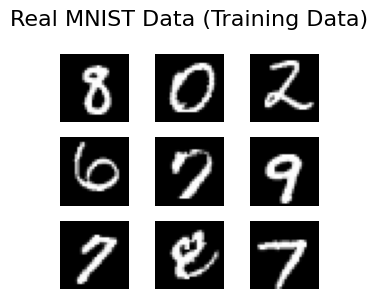

In [3]:
dataloader = load_data(batch_size=64)
real_images, labels = next(iter(dataloader))

print(f"Batch image shape: {real_images.shape}") 
print(f"Value range: Min = {real_images.min().item()}, Max = {real_images.max().item()}")


plot_images(real_images[:9] , 3, "Real MNIST Data (Training Data)")

**Generator Architecture**

In [4]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100, h=64, channels=1):
        super(Generator, self).__init__()
        
        self.net = nn.Sequential(

            nn.ConvTranspose2d(latent_dim, h * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h * 4, h * 2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h * 2, h, 4, 2, 1, bias=False),
            nn.BatchNorm2d(h),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(h, channels, 4, 2, 1, bias=False),

            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)

**Discriminator Architecture**

In [ ]:
class Critic(nn.Module):
    def __init__(self, h=64, channels=1):
        super(Critic, self).__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(channels, h, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h, h * 2, 4, 2, 1, bias=False),
            nn.LayerNorm([h * 2, 7, 7]),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h * 2, h * 4, 3, 2, 1, bias=False),
            nn.LayerNorm([h * 4, 4, 4]),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(h * 4, 1, 4, 1, 0, bias=False),
        )


    def forward(self, x):
        return self.net(x).view(-1, 1)

**Weight Initialization**

drawing weights from a normal distribution with a mean of 0 and a standard deviation of 0.02 for Conv layers and mean 1 , std 0.02 for BatchNorm

In [6]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('Norm') != -1: 
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


**Instance & sanity check**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100

netG = Generator(latent_dim=latent_dim).to(device)
netC = Critic().to(device)

netG.apply(weights_init)
netC.apply(weights_init)

print(netG)
print(netC)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=

**Configs**

set as Algorithm 1 of WGAN-GP paper

**Important: n_critic**

n_critic was set to 5 in the paper, meaning the Critic trains for 5 steps before the Generator gets to train 1 time.
We later want to compare this model results to Naive GAN, simply training each one for 30 epochs isn't enough.
because Critic only updates 6 times but Discriminator in Naive GAN updates 30 times.
so I lowered n_critic to 2

In [8]:
import torch.optim as optim

lambda_gp = 10
n_critic = 2
lr = 0.0001

optimizerC = optim.Adam(netC.parameters(), lr=lr, betas=(0.0, 0.9))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.0, 0.9))
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

G_losses = []
C_losses = []


**Training Loop**

**Cirtic**:

maximize:$$\mathbb{E}_{x \sim \mathbb{P}_r}[D(x)] - \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[D(\tilde{x})]$$

or minimuze: $$L_{Critic} = - \mathbb{E}_{x \sim \mathbb{P}_r}[D(x)] + \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[D(\tilde{x})]$$

pushes real scores up and fake scores down

but for WGAN math to work we need the Critic's function to be 1-Lipschitz (slope not too steep). we can ensure this by introducing a penalty for the gradient.

$$L_{Critic} = \underbrace{\mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[D(\tilde{x})] - \mathbb{E}_{x \sim \mathbb{P}_r}[D(x)]}_{\text{Original Critic Loss}} + \underbrace{\lambda \mathbb{E}_{\hat{x} \sim \mathbb{P}_{\hat{x}}}[(||\nabla_{\hat{x}}D(\hat{x})||_2 - 1)^2]}_{\text{Gradient Penalty}}$$

$\hat{x}$ (Interpolates): These are artificial images created by drawing a straight line between a real image and a fake image, and picking a random point on that line.

$\nabla_{\hat{x}}D(\hat{x})$: This is the gradient of the Critic's output with respect to the pixels of that interpolated image.


**Generator**:

maximize: $$\mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[D(\tilde{x})]$$

or minimize: $$L_{Generator} = - \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[D(\tilde{x})]$$

In [9]:
import torch.autograd as autograd

def calculate_gradient_penalty(critic, real_samples, fake_samples, device):

    real_prob = torch.rand((real_samples.size(0), 1, 1, 1), device=device)
    
    x_hat = (real_prob * real_samples + ((1 - real_prob) * fake_samples)).requires_grad_(True)
    
    d_x_hat = critic(x_hat)
    
    fake_labels = torch.ones((real_samples.size(0), 1), device=device)
    
    grad_d_x_hat = autograd.grad(
        outputs=d_x_hat,
        inputs=x_hat,
        grad_outputs=fake_labels,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    grad_d_x_hat = grad_d_x_hat.view(grad_d_x_hat.size(0), -1)
    
    gradient_penalty = ((grad_d_x_hat.norm(2, dim=1) - 1) ** 2).mean()
    
    return gradient_penalty

[1/30][0/937] Loss_C: 29.6243 Loss_G: -0.3491 Wasserstein Dist: -0.6504 Gradient Penalty: 2.897383
[1/30][500/937] Loss_C: -2.8352 Loss_G: 5.0448 Wasserstein Dist: 3.4140 Gradient Penalty: 0.057884


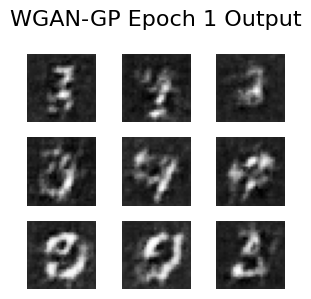

[2/30][0/937] Loss_C: -4.0457 Loss_G: 10.7404 Wasserstein Dist: 5.1594 Gradient Penalty: 0.111378
[2/30][500/937] Loss_C: -4.0185 Loss_G: 11.6821 Wasserstein Dist: 4.1461 Gradient Penalty: 0.012759
[3/30][0/937] Loss_C: -3.5241 Loss_G: 14.6945 Wasserstein Dist: 3.6422 Gradient Penalty: 0.011815
[3/30][500/937] Loss_C: -3.4340 Loss_G: 17.6295 Wasserstein Dist: 3.6101 Gradient Penalty: 0.017601
[4/30][0/937] Loss_C: -3.2658 Loss_G: 19.4628 Wasserstein Dist: 3.7639 Gradient Penalty: 0.049812
[4/30][500/937] Loss_C: -2.2830 Loss_G: 17.0024 Wasserstein Dist: 2.5379 Gradient Penalty: 0.025493
[5/30][0/937] Loss_C: -2.1357 Loss_G: 17.0068 Wasserstein Dist: 2.4876 Gradient Penalty: 0.035197
[5/30][500/937] Loss_C: -2.0059 Loss_G: 15.0920 Wasserstein Dist: 2.1085 Gradient Penalty: 0.010262
[6/30][0/937] Loss_C: -2.2367 Loss_G: 13.2244 Wasserstein Dist: 2.5474 Gradient Penalty: 0.031064
[6/30][500/937] Loss_C: -1.8123 Loss_G: 15.2936 Wasserstein Dist: 2.0963 Gradient Penalty: 0.028404


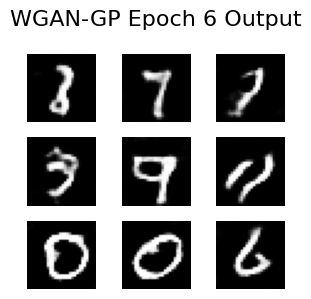

[7/30][0/937] Loss_C: -1.5411 Loss_G: 14.0088 Wasserstein Dist: 1.8772 Gradient Penalty: 0.033611
[7/30][500/937] Loss_C: -2.3532 Loss_G: 13.0740 Wasserstein Dist: 2.5095 Gradient Penalty: 0.015630
[8/30][0/937] Loss_C: -1.8996 Loss_G: 12.5717 Wasserstein Dist: 2.0565 Gradient Penalty: 0.015683
[8/30][500/937] Loss_C: -2.0359 Loss_G: 10.7847 Wasserstein Dist: 2.1703 Gradient Penalty: 0.013438
[9/30][0/937] Loss_C: -2.0424 Loss_G: 10.8606 Wasserstein Dist: 2.4146 Gradient Penalty: 0.037224
[9/30][500/937] Loss_C: -1.5190 Loss_G: 10.8456 Wasserstein Dist: 1.9489 Gradient Penalty: 0.042984
[10/30][0/937] Loss_C: -1.8018 Loss_G: 10.5296 Wasserstein Dist: 2.0069 Gradient Penalty: 0.020515
[10/30][500/937] Loss_C: -1.4902 Loss_G: 10.4735 Wasserstein Dist: 1.8180 Gradient Penalty: 0.032779
[11/30][0/937] Loss_C: -1.5303 Loss_G: 10.5064 Wasserstein Dist: 1.7958 Gradient Penalty: 0.026554
[11/30][500/937] Loss_C: -1.9065 Loss_G: 9.9763 Wasserstein Dist: 2.0160 Gradient Penalty: 0.010957


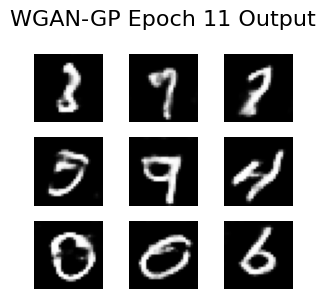

[12/30][0/937] Loss_C: -1.4326 Loss_G: 9.7787 Wasserstein Dist: 1.7155 Gradient Penalty: 0.028288
[12/30][500/937] Loss_C: -1.4968 Loss_G: 10.7721 Wasserstein Dist: 1.6573 Gradient Penalty: 0.016049
[13/30][0/937] Loss_C: -1.7603 Loss_G: 9.6085 Wasserstein Dist: 2.0620 Gradient Penalty: 0.030171
[13/30][500/937] Loss_C: -1.3699 Loss_G: 9.5255 Wasserstein Dist: 1.6502 Gradient Penalty: 0.028021
[14/30][0/937] Loss_C: -1.7625 Loss_G: 10.2409 Wasserstein Dist: 2.0620 Gradient Penalty: 0.029943
[14/30][500/937] Loss_C: -1.2813 Loss_G: 9.4357 Wasserstein Dist: 1.4496 Gradient Penalty: 0.016835
[15/30][0/937] Loss_C: -1.5544 Loss_G: 8.1492 Wasserstein Dist: 1.7485 Gradient Penalty: 0.019409
[15/30][500/937] Loss_C: -1.2999 Loss_G: 9.3297 Wasserstein Dist: 1.4402 Gradient Penalty: 0.014033
[16/30][0/937] Loss_C: -1.8787 Loss_G: 7.0297 Wasserstein Dist: 2.0334 Gradient Penalty: 0.015463
[16/30][500/937] Loss_C: -1.4828 Loss_G: 9.8918 Wasserstein Dist: 1.7950 Gradient Penalty: 0.031213


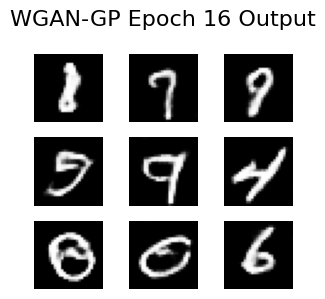

[17/30][0/937] Loss_C: -1.4091 Loss_G: 9.6198 Wasserstein Dist: 1.5309 Gradient Penalty: 0.012181
[17/30][500/937] Loss_C: -1.3949 Loss_G: 9.7417 Wasserstein Dist: 1.5340 Gradient Penalty: 0.013901
[18/30][0/937] Loss_C: -1.2302 Loss_G: 8.5162 Wasserstein Dist: 1.3046 Gradient Penalty: 0.007438
[18/30][500/937] Loss_C: -1.4853 Loss_G: 9.3333 Wasserstein Dist: 1.7139 Gradient Penalty: 0.022853
[19/30][0/937] Loss_C: -1.0964 Loss_G: 8.5199 Wasserstein Dist: 1.3018 Gradient Penalty: 0.020542
[19/30][500/937] Loss_C: -1.2098 Loss_G: 9.3300 Wasserstein Dist: 1.3178 Gradient Penalty: 0.010804
[20/30][0/937] Loss_C: -1.1776 Loss_G: 8.6949 Wasserstein Dist: 1.3625 Gradient Penalty: 0.018492
[20/30][500/937] Loss_C: -0.9854 Loss_G: 8.5702 Wasserstein Dist: 1.3117 Gradient Penalty: 0.032627
[21/30][0/937] Loss_C: -1.1874 Loss_G: 8.3738 Wasserstein Dist: 1.3495 Gradient Penalty: 0.016204
[21/30][500/937] Loss_C: -1.4224 Loss_G: 8.9509 Wasserstein Dist: 1.7557 Gradient Penalty: 0.033330


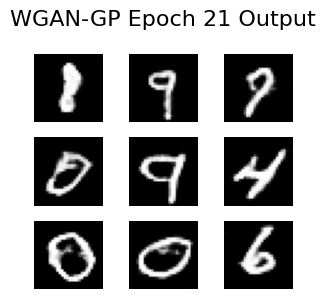

[22/30][0/937] Loss_C: -1.4976 Loss_G: 8.4330 Wasserstein Dist: 1.5928 Gradient Penalty: 0.009520
[22/30][500/937] Loss_C: -1.1113 Loss_G: 8.9177 Wasserstein Dist: 1.2478 Gradient Penalty: 0.013647
[23/30][0/937] Loss_C: -1.3726 Loss_G: 7.7612 Wasserstein Dist: 1.6613 Gradient Penalty: 0.028871
[23/30][500/937] Loss_C: -1.5753 Loss_G: 8.8795 Wasserstein Dist: 1.6855 Gradient Penalty: 0.011022
[24/30][0/937] Loss_C: -1.2834 Loss_G: 9.3116 Wasserstein Dist: 1.4260 Gradient Penalty: 0.014258
[24/30][500/937] Loss_C: -0.9408 Loss_G: 8.7098 Wasserstein Dist: 1.1352 Gradient Penalty: 0.019443
[25/30][0/937] Loss_C: -1.3209 Loss_G: 9.9002 Wasserstein Dist: 1.4925 Gradient Penalty: 0.017163
[25/30][500/937] Loss_C: -1.6850 Loss_G: 7.7376 Wasserstein Dist: 1.8007 Gradient Penalty: 0.011579
[26/30][0/937] Loss_C: -1.0920 Loss_G: 8.4944 Wasserstein Dist: 1.3250 Gradient Penalty: 0.023304
[26/30][500/937] Loss_C: -1.2145 Loss_G: 9.2290 Wasserstein Dist: 1.3773 Gradient Penalty: 0.016288


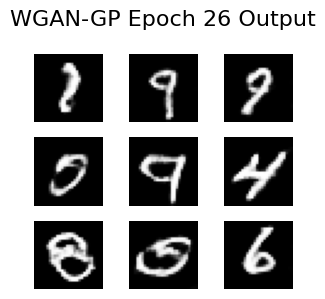

[27/30][0/937] Loss_C: -1.3466 Loss_G: 8.1124 Wasserstein Dist: 1.4931 Gradient Penalty: 0.014649
[27/30][500/937] Loss_C: -1.1750 Loss_G: 8.3242 Wasserstein Dist: 1.3463 Gradient Penalty: 0.017131
[28/30][0/937] Loss_C: -1.0330 Loss_G: 9.9881 Wasserstein Dist: 1.3018 Gradient Penalty: 0.026881
[28/30][500/937] Loss_C: -1.4673 Loss_G: 8.0583 Wasserstein Dist: 1.6487 Gradient Penalty: 0.018140
[29/30][0/937] Loss_C: -1.1875 Loss_G: 8.0776 Wasserstein Dist: 1.2860 Gradient Penalty: 0.009846
[29/30][500/937] Loss_C: -1.4684 Loss_G: 8.8856 Wasserstein Dist: 1.6348 Gradient Penalty: 0.016638
[30/30][0/937] Loss_C: -1.1283 Loss_G: 9.7468 Wasserstein Dist: 1.3383 Gradient Penalty: 0.020995
[30/30][500/937] Loss_C: -1.4103 Loss_G: 7.4178 Wasserstein Dist: 1.5503 Gradient Penalty: 0.014001


In [10]:
num_epochs = 30

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        
        real = data[0].to(device)
        b_size = real.size(0)

        # C Network
        optimizerC.zero_grad()
        
        z = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake = netG(z).detach()
        
        real_score = netC(real)

        fake_score = netC(fake)
        
        gp = calculate_gradient_penalty(netC, real.data, fake.data, device)

        avg_real_scoe = torch.mean(real_score)
        avg_fake_score = torch.mean(fake_score)
        
        c_loss = -avg_real_scoe + avg_fake_score + lambda_gp * gp
        
        c_loss.backward()
        optimizerC.step()
        
        # G Network
        if i % n_critic == 0:
            optimizerG.zero_grad()
            
            gen_z = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fakes = netG(gen_z)
            
            c_fake_score = netC(fakes)
            g_loss = -torch.mean(c_fake_score)
            
            g_loss.backward()
            optimizerG.step()
            
            G_losses.append(g_loss.item())
            C_losses.append(c_loss.item())
            
        if i % 500 == 0:
            print(f'[{epoch+1}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_C: {c_loss.item():.4f} Loss_G: {g_loss.item():.4f} '
                  f'Wasserstein Dist: {(avg_real_scoe- avg_fake_score).item():.4f}'
                  f' Gradient Penalty: {gp:4f}')

    if epoch % 5 == 0:
        with torch.no_grad():
            fake_images = netG(fixed_noise).detach().cpu()
        plot_images(fake_images[:9], num_cols=3, title=f"WGAN-GP Epoch {epoch + 1} Output")

torch.save(netG.state_dict(), 'wgangp_generator.pth')
torch.save(netC.state_dict(), 'wgangp_critic.pth')

**Analysis**

- loss Discriminator much lower than loss Generator and by D(x) we undertand that discriminator is stronger than generator. Still, gradient didn't vanish and generator updates.
- visually, the results are acceptable. Also we have a good mixture of numbers so mode collapase hasn't occured

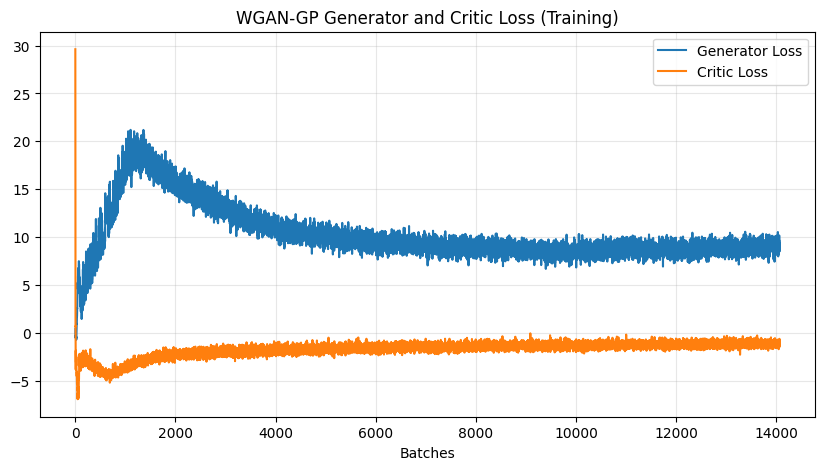

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.title("WGAN-GP Generator and Critic Loss (Training)")
plt.plot(G_losses, label="Generator Loss")
plt.plot(C_losses, label="Critic Loss")
plt.xlabel("Batches")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

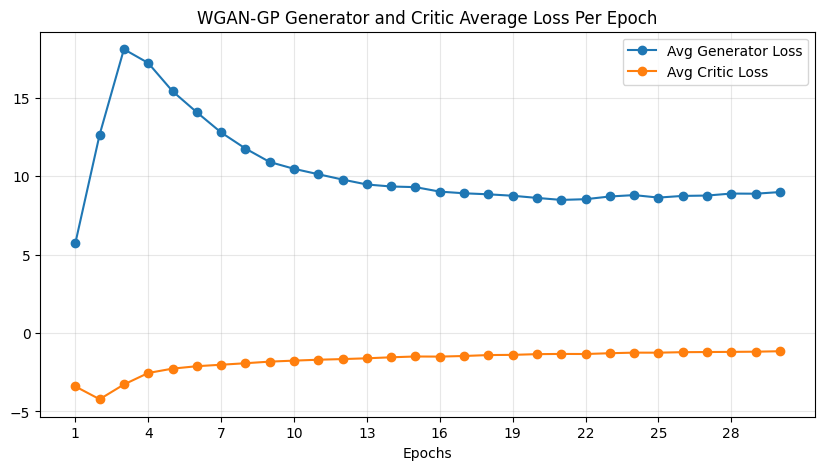

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

updates_per_epoch = len(dataloader) // n_critic

actual_epochs = len(G_losses) // updates_per_epoch

G_losses_epoch = np.array(G_losses[:actual_epochs * updates_per_epoch]).reshape(actual_epochs, -1).mean(axis=1)
C_losses_epoch = np.array(C_losses[:actual_epochs * updates_per_epoch]).reshape(actual_epochs, -1).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.title("WGAN-GP Generator and Critic Average Loss Per Epoch")
plt.plot(range(1, actual_epochs + 1), G_losses_epoch, label="Avg Generator Loss", color='#1f77b4', marker='o')
plt.plot(range(1, actual_epochs + 1), C_losses_epoch, label="Avg Critic Loss", color='#ff7f0e', marker='o')

plt.xlabel("Epochs")
plt.xticks(range(1, actual_epochs + 1, max(1, actual_epochs // 10)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

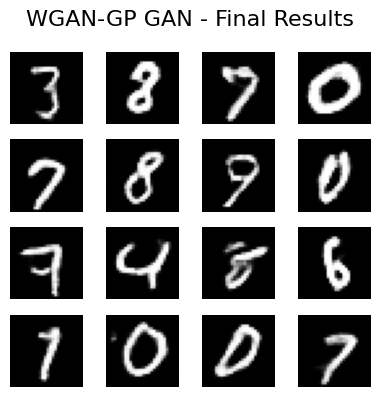

In [15]:
netG.eval() 

with torch.no_grad():
    final_noise = torch.randn(16, latent_dim, 1, 1, device=device)
    final_fakes = netG(final_noise)

plot_images(final_fakes, num_cols=4, title="WGAN-GP GAN - Final Results")

In [16]:
!pip install torch-fidelity
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm
!pip install torch-fidelity
import math

def calculate_fid(generator, dataloader, device, num_samples=1000):

    print(f"Calculating FID over {num_samples} samples...")
    
    fid = FrechetInceptionDistance(feature=2048).to(device)
    generator.eval()
    
    samples_processed = 0
    expected_batches = math.ceil(num_samples / 64)

    for real_batch, _ in tqdm(dataloader, desc="Extracting Features", total=expected_batches):
        if samples_processed >= num_samples:
            break
            
        b_size = real_batch.size(0)
        
        real_images = ((real_batch + 1) / 2 * 255).byte().to(device)

        real_images = real_images.repeat(1, 3, 1, 1)
        
        with torch.no_grad():
            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_batch = generator(noise)
            
        fake_images = ((fake_batch + 1) / 2 * 255).byte().to(device)
        fake_images = fake_images.repeat(1, 3, 1, 1)
        
        fid.update(real_images, real=True)
        fid.update(fake_images, real=False)
        
        samples_processed += b_size
        
    fid_score = fid.compute().item()
    print(f"\nFinal FID Score: {fid_score:.4f}")
    
    fid.reset() 
    return fid_score

wgangp_fid = calculate_fid(netG, dataloader, device, num_samples=10000)

Calculating FID over 10000 samples...


Extracting Features: 100%|██████████| 157/157 [01:24<00:00,  1.86it/s]



Final FID Score: 9.5857
